In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import geopandas as gpd

# Mini-Lab: Geospatial Vector Operations

In this lab, you will learn how to work with **Geopandas** and **Shapely** to plot geospatial data, creating a map and an associated chloropleth in the process.

Start by using `gpd.read_file()` to read in the `.shp` file in the shapefile_us folder.

In [3]:
states_shape = gpd.read_file('shapefile_us/cb_2018_us_state_500k.shp')
states_shape

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,28,01779790,0400000US28,28,MS,Mississippi,00,121533519481,3926919758,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ..."
1,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
2,40,01102857,0400000US40,40,OK,Oklahoma,00,177662925723,3374587997,"POLYGON ((-103.00256 36.52659, -103.00219 36.6..."
3,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ..."
4,54,01779805,0400000US54,54,WV,West Virginia,00,62266474513,489028543,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."
5,22,01629543,0400000US22,22,LA,Louisiana,00,111897594374,23753621895,"MULTIPOLYGON (((-88.8677 29.86155, -88.86566 2..."
6,26,01779789,0400000US26,26,MI,Michigan,00,146600952990,103885855702,"MULTIPOLYGON (((-83.19159 42.03537, -83.18993 ..."
7,25,00606926,0400000US25,25,MA,Massachusetts,00,20205125364,7129925486,"MULTIPOLYGON (((-70.23405 41.28565, -70.22361 ..."
8,16,01779783,0400000US16,16,ID,Idaho,00,214049787659,2391722557,"POLYGON ((-117.24267 44.39655, -117.23484 44.3..."
9,12,00294478,0400000US12,12,FL,Florida,00,138949136250,31361101223,"MULTIPOLYGON (((-80.17628 25.52505, -80.17395 ..."


This polygon should look familiar to you.

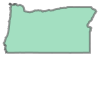

In [4]:
states_shape["geometry"][50]

The following code will print the coordinates of all of the polygons that make up Oregon.

In [6]:
[np.array(g.boundary.xy) for g in states_shape["geometry"][50].geoms]

[array([[-123.598916, -123.598414, -123.595363, -123.591393, -123.588049,
         -123.581571, -123.576598, -123.573631, -123.572962, -123.573171,
         -123.574843, -123.576556, -123.578019, -123.579147, -123.580903,
         -123.582491, -123.583745, -123.585751, -123.58667 , -123.588927,
         -123.590014, -123.591476, -123.592187, -123.594695, -123.595321,
         -123.596116, -123.597035, -123.597787, -123.598498, -123.599083,
         -123.598916],
        [  46.251454,   46.251628,   46.252408,   46.25235 ,   46.251975,
           46.251454,   46.250761,   46.250212,   46.249807,   46.249345,
           46.249113,   46.249084,   46.249373,   46.249778,   46.249749,
           46.249431,   46.248998,   46.250414,   46.250356,   46.250905,
           46.251165,   46.250847,   46.250819,   46.251512,   46.251541,
           46.251079,   46.250327,   46.250096,   46.250183,   46.250963,
           46.251454]]),
 array([[-123.66614 , -123.665291, -123.664611, -123.664654, -12

Note that every geoDataFrame should have an associated projection. Here we'll us "EPSG:4326", a widely used projection. 

In [7]:
states_shape.set_crs("EPSG:4326", allow_override=True)

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,28,01779790,0400000US28,28,MS,Mississippi,00,121533519481,3926919758,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ..."
1,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
2,40,01102857,0400000US40,40,OK,Oklahoma,00,177662925723,3374587997,"POLYGON ((-103.00256 36.52659, -103.00219 36.6..."
3,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ..."
4,54,01779805,0400000US54,54,WV,West Virginia,00,62266474513,489028543,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."
5,22,01629543,0400000US22,22,LA,Louisiana,00,111897594374,23753621895,"MULTIPOLYGON (((-88.8677 29.86155, -88.86566 2..."
6,26,01779789,0400000US26,26,MI,Michigan,00,146600952990,103885855702,"MULTIPOLYGON (((-83.19159 42.03537, -83.18993 ..."
7,25,00606926,0400000US25,25,MA,Massachusetts,00,20205125364,7129925486,"MULTIPOLYGON (((-70.23405 41.28565, -70.22361 ..."
8,16,01779783,0400000US16,16,ID,Idaho,00,214049787659,2391722557,"POLYGON ((-117.24267 44.39655, -117.23484 44.3..."
9,12,00294478,0400000US12,12,FL,Florida,00,138949136250,31361101223,"MULTIPOLYGON (((-80.17628 25.52505, -80.17395 ..."


### Part 1: Simple plotting

To start, use the `plot()` method associated with your geoDataFrame to create the map.

<Axes: >

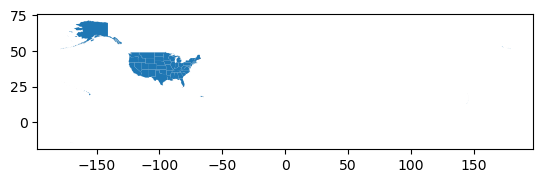

In [8]:
states_shape.plot()

It should be clear that the lat-long limits are too wide if we're just interested in viewing the US. Let's pretend for now that Alaska and Hawaii don't exist and just zoom in on the continential US. Change your axis limits accordingly.

(20.0, 55.0)

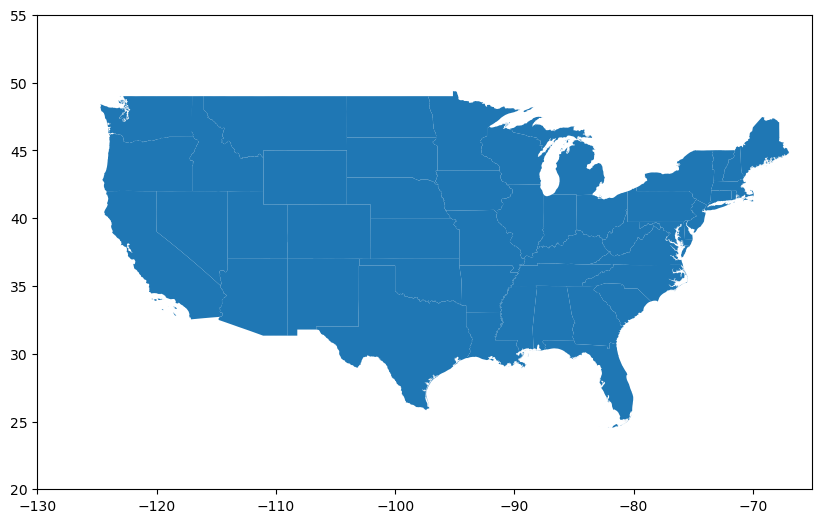

In [24]:
states_shape.plot(figsize = (10, 10))
plt.xlim(-130, -65)
plt.ylim(20, 55)

Perhaps we don't like the blue fill with white outlines. Change the `color` and `edgecolor` to a white fill with black outlines. Ensure there are appropriate axis labels now.

Text(91.97222222222221, 0.5, 'Latitude')

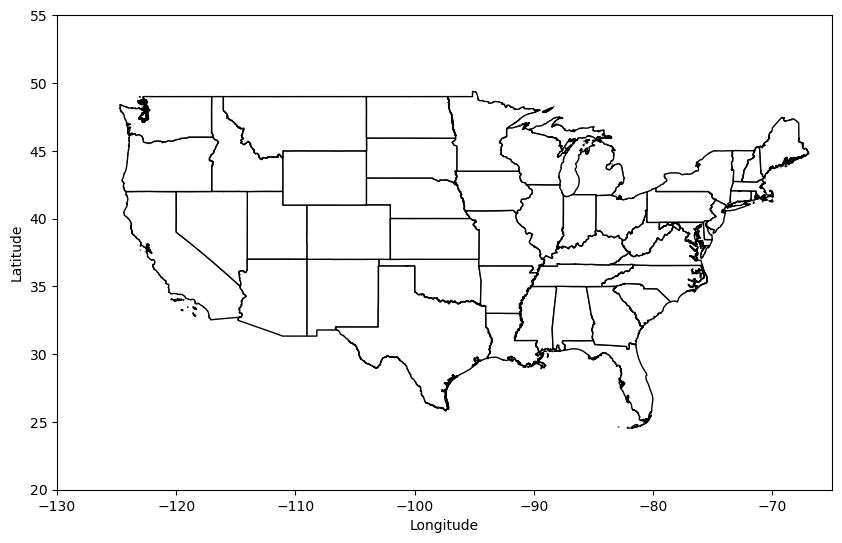

In [71]:
states_shape.plot(color = 'white', edgecolor = 'black', figsize = (10, 10))
plt.xlim(-130, -65)
plt.ylim(20, 55)

plt.xlabel('Longitude')
plt.ylabel('Latitude')

### Part 2: Geometries and adding layers

A map of the US is fine and all but not necessarily relevatory. Let's incorporate new information to understand it geospatially! 

Read in "US_earthquakes" and subset it for only type == earthquake.

In [102]:
eqs = pd.read_csv('data/US_earthquakes.csv')
eqs = us_earthquakes[eqs['type'] == 'earthquake']
eqs

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_74483/2922791617.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  eqs = us_earthquakes[eqs['type'] == 'earthquake']


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-01-21T15:35:09.710Z,37.178333,-118.264503,5.7500,2.72,md,28.0,164.0,0.054280,0.08,...,2025-01-21T20:17:08.495Z,"3 km ENE of Big Pine, CA",earthquake,0.650000,0.600000,0.220000,36.0,automatic,nc,nc
1,2025-01-21T13:25:30.570Z,36.958832,-121.596336,3.4500,2.64,md,67.0,40.0,0.011980,0.19,...,2025-01-22T04:24:25.066Z,"6 km SW of Gilroy, CA",earthquake,0.210000,0.380000,0.120000,78.0,automatic,nc,nc
2,2025-01-21T10:44:47.050Z,37.691167,-111.301667,13.5900,3.46,ml,27.0,153.0,0.506500,0.22,...,2025-01-22T18:27:48.113Z,"26 km SSE of Boulder Town, Utah",earthquake,0.760000,1.110000,0.142907,25.0,reviewed,uu,uu
3,2025-01-21T07:55:23.730Z,33.682667,-116.802333,16.6100,2.71,ml,122.0,17.0,0.064790,0.21,...,2025-01-22T06:21:26.728Z,"10 km SW of Idyllwild, CA",earthquake,0.110000,0.290000,0.183000,195.0,reviewed,ci,ci
4,2025-01-21T06:29:04.238Z,35.573000,-101.001000,5.9326,2.60,ml,15.0,75.0,0.500000,0.30,...,2025-01-21T19:55:38.135Z,"5 km NW of Pampa, Texas",earthquake,2.321471,2.136415,0.100000,11.0,reviewed,tx,tx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16210,2020-01-15T12:16:30.970Z,33.850833,-117.657500,7.3800,2.89,ml,131.0,17.0,0.046760,0.18,...,2024-10-14T22:15:14.770Z,"9km WSW of Corona, CA",earthquake,0.090000,0.260000,0.152000,179.0,reviewed,ci,ci
16211,2020-01-15T08:49:20.490Z,32.349667,-115.358000,11.4900,2.67,ml,30.0,118.0,0.082820,0.25,...,2020-04-08T19:40:09.040Z,"16km W of Delta, B.C., MX",earthquake,0.380000,0.770000,0.158000,60.0,reviewed,ci,ci
16212,2020-01-15T07:00:37.860Z,37.942333,-122.313333,6.7000,2.62,md,112.0,23.0,0.013850,0.08,...,2020-04-08T19:40:08.040Z,"0km S of East Richmond Heights, CA",earthquake,0.090000,0.130000,0.166000,117.0,reviewed,nc,nc
16213,2020-01-15T05:02:41.610Z,35.580167,-117.414167,5.9500,2.50,ml,51.0,35.0,0.005488,0.16,...,2021-10-12T19:13:18.840Z,"21km S of Trona, CA",earthquake,0.140000,0.240000,0.144000,78.0,reviewed,ci,ci


Now plot the location of all earthquakes on your map. Be sure to change the color of the points to something other than black, and make them small enough to pick up detail in their geographic distribution.

(20.0, 55.0)

<Figure size 1000x1000 with 0 Axes>

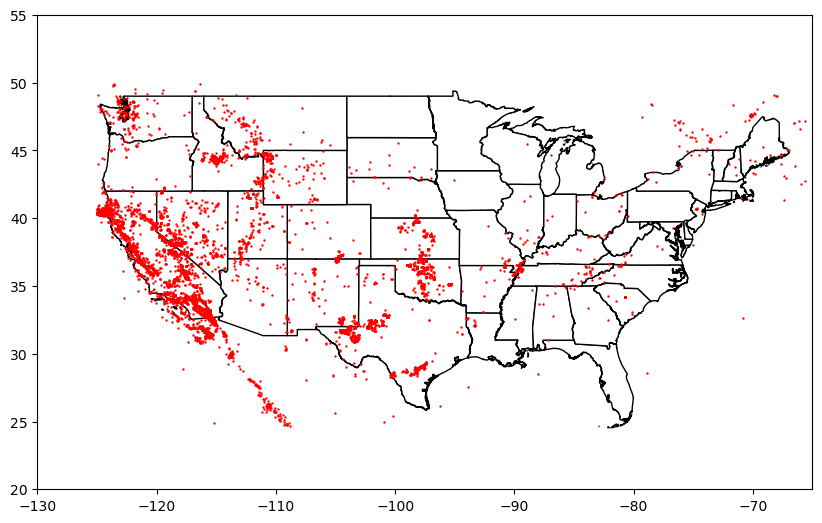

In [110]:
plt.figure(figsize = (10, 10))

states_shape.plot(color = 'white', edgecolor = 'black', figsize = (10, 10))

plt.scatter(eqs['longitude'], us_earthquakes['latitude'], color = 'red', marker = 'o', s = 0.5)

plt.xlim(-130, -65)
plt.ylim(20, 55)

This map in and of itself is pretty interesting (or should be if you've done it right). Note that not all of the locations of the earthquakes are contained within the US. 

It would be easier to visualize where we see the most earthquakes by converting this figure into a chloropleth. To do so, we'll use the earthquakes data to determine the density of earthquakes (earthquakes/area) in each state. This will involve merging the lat/long associated with each earthquake with the multipolygons associated with each state.

You're going to need [Point](https://shapely.readthedocs.io/en/2.0.6/reference/shapely.Point.html) from shapely. Create a [GeoDataFrame](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.html) with `geometry` equal to you lat/longs converted to Point data.

You might want to use a for loop to create the Points.

In [112]:
from shapely import Point

# Convert your pairs of lat/long to Points

point_locs = gpd.GeoDataFrame(geometry = [Point(lon, lat) for lat, lon in zip(
    eqs['latitude'], eqs['longitude'])], crs = 'EPSG:4269')

point_locs

,geometry
0,POINT (-118.2645 37.17833)
1,POINT (-121.59634 36.95883)
2,POINT (-111.30167 37.69117)
3,POINT (-116.80233 33.68267)
4,POINT (-101.001 35.573)
...,...
15178,POINT (-117.6575 33.85083)
15179,POINT (-115.358 32.34967)
15180,POINT (-122.31333 37.94233)
15181,POINT (-117.41417 35.58017)


Use [sjoin](https://geopandas.org/en/stable/docs/reference/api/geopandas.sjoin.html) to left join the states data on your earthquake points. `sjoin()` automatically joins both objects on the "geometry" column (this is unlike regular joins that require a specified key). `sjoin` can join Points, Lines and Polygons where they either partially or totally overlap. In this particular case, rows will join if a Point is contained within a Polygon.

If you run into a CRS mismatch warning, be sure to set the `crs` when creating your GeoDataFrame of Points in the above section.

In [113]:
# Perform the spatial join


joined = gpd.sjoin(point_locs, states_shape, how = 'left')
joined

,geometry,index_right,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER
0,POINT (-118.2645 37.17833),16.0,06,01779778,0400000US06,06,CA,California,00,4.035039e+11,2.046387e+10
1,POINT (-121.59634 36.95883),16.0,06,01779778,0400000US06,06,CA,California,00,4.035039e+11,2.046387e+10
2,POINT (-111.30167 37.69117),22.0,49,01455989,0400000US49,49,UT,Utah,00,2.128862e+11,6.998824e+09
3,POINT (-116.80233 33.68267),16.0,06,01779778,0400000US06,06,CA,California,00,4.035039e+11,2.046387e+10
4,POINT (-101.001 35.573),15.0,48,01779801,0400000US48,48,TX,Texas,00,6.766532e+11,1.900631e+10
...,...,...,...,...,...,...,...,...,...,...,...
15178,POINT (-117.6575 33.85083),16.0,06,01779778,0400000US06,06,CA,California,00,4.035039e+11,2.046387e+10
15179,POINT (-115.358 32.34967),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15180,POINT (-122.31333 37.94233),16.0,06,01779778,0400000US06,06,CA,California,00,4.035039e+11,2.046387e+10
15181,POINT (-117.41417 35.58017),16.0,06,01779778,0400000US06,06,CA,California,00,4.035039e+11,2.046387e+10


Now count the number of earthquakes associated with each states. If you used the correct DF as your left frame, each row should represent a separate earthquake.

In [121]:
# Earthquakes per state
eqs_count = joined.groupby('NAME').size().reset_index()
# eqs_count['NAME'].value_counts()
eqs_count.head()

,NAME,0
0,Alabama,8
1,Arizona,61
2,Arkansas,37
3,California,4651
4,Colorado,79


Now merge these counts back on the original states_shape frame and create a new variable associated with the density of earthquakes, which is the number of quakes in each state divided by its ALAND. Replace any NA values for number of quakes with 0.

In [126]:
merge = states_shape.merge(eqs_count, on = 'NAME', how = 'left')
merge[0] = merge[0].fillna(0)
merge['density'] = merge[0] / merge['ALAND']
merge

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry,0,density
0,28,01779790,0400000US28,28,MS,Mississippi,00,121533519481,3926919758,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ...",2.0,1.645637e-11
1,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ...",11.0,8.735452e-11
2,40,01102857,0400000US40,40,OK,Oklahoma,00,177662925723,3374587997,"POLYGON ((-103.00256 36.52659, -103.00219 36.6...",432.0,2.431571e-09
3,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ...",9.0,8.801292e-11
4,54,01779805,0400000US54,54,WV,West Virginia,00,62266474513,489028543,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,...",1.0,1.606001e-11
5,22,01629543,0400000US22,22,LA,Louisiana,00,111897594374,23753621895,"MULTIPOLYGON (((-88.8677 29.86155, -88.86566 2...",17.0,1.519246e-10
6,26,01779789,0400000US26,26,MI,Michigan,00,146600952990,103885855702,"MULTIPOLYGON (((-83.19159 42.03537, -83.18993 ...",0.0,0.000000e+00
7,25,00606926,0400000US25,25,MA,Massachusetts,00,20205125364,7129925486,"MULTIPOLYGON (((-70.23405 41.28565, -70.22361 ...",1.0,4.949239e-11
8,16,01779783,0400000US16,16,ID,Idaho,00,214049787659,2391722557,"POLYGON ((-117.24267 44.39655, -117.23484 44.3...",1575.0,7.358101e-09
9,12,00294478,0400000US12,12,FL,Florida,00,138949136250,31361101223,"MULTIPOLYGON (((-80.17628 25.52505, -80.17395 ...",0.0,0.000000e+00


At long last, replot your states map but with the number of earthquakes plotted as well (`column = ` in `plot`). Use a sequential color palette such brighter colors = more earthquakes. 

(20.0, 55.0)

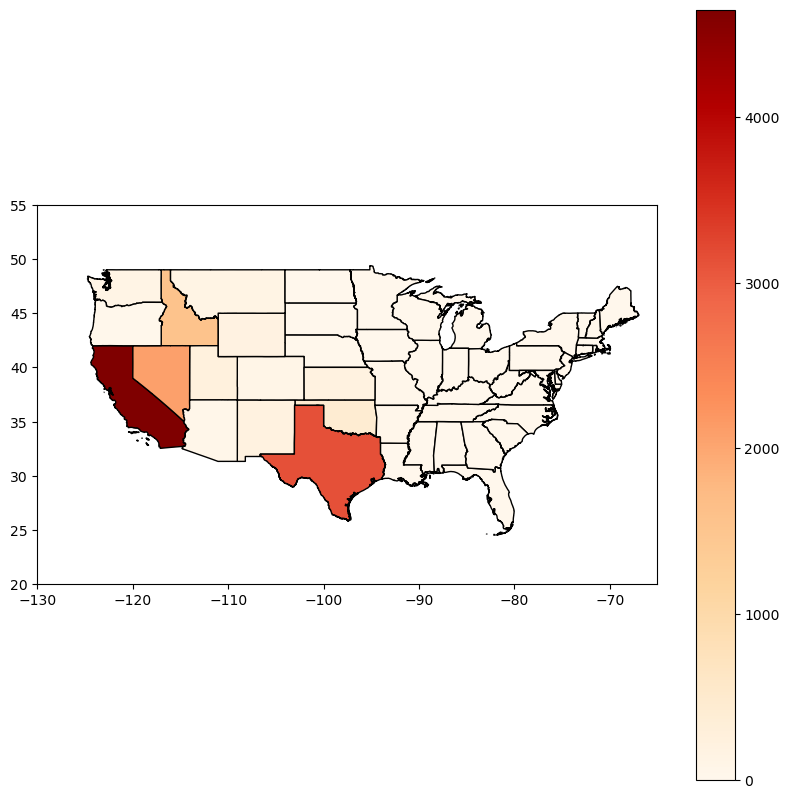

In [132]:
merge.plot(figsize = (10, 10), column = 0, cmap = 'OrRd', edgecolor = 'black', legend = True)

plt.xlim(-130, -65)
plt.ylim(20, 55)

Because the range of values is fairly large, you may notice that it's hard to tell which states have relatively low vs essentially 0 earthquakes. In this case we might prefer to bin the values and use more distinct colors for each bin. Install the `mapclassify` package and set `scheme = "quantiles"` in `plot`. 

(20.0, 55.0)

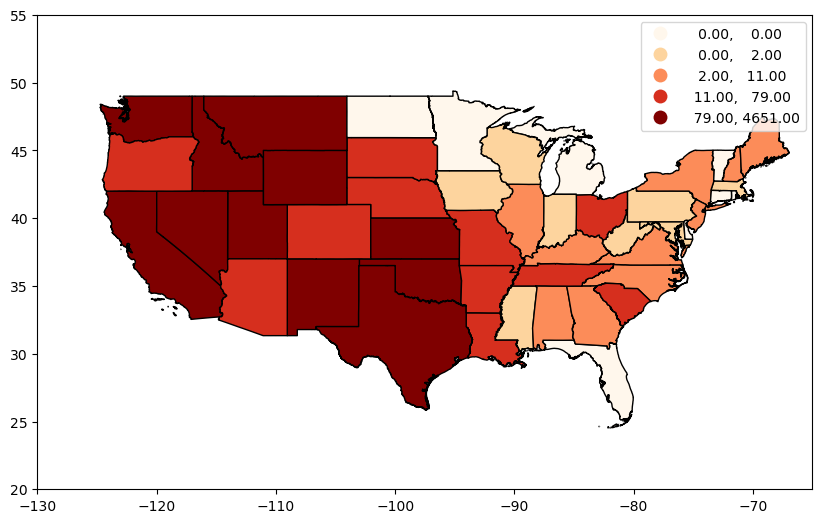

In [134]:
# Remake the map
merge.plot(figsize = (10, 10), column = 0, cmap = 'OrRd', edgecolor = 'black', legend = True, scheme = 'quantiles')

plt.xlim(-130, -65)
plt.ylim(20, 55)

Which of the two versions of the map do you prefer? Explain your answer in 2-4 sentences.

**Your response:** I would say that the second graph is much better, because we can actually see clearly now the emount of earthquakes that happen in other states and can differentiate them to states that have none. Since our original graph had a very large range due to california having many, we weren't able to tell if the central states actually had earthquakes or not, and roughly how many. With this new graph, we are able to tell right away. 

That's it for this lab. You learned how to plot a map, layer points on top, and map those points to their associated polygons to create a chloropleth. Equipped with these tools, you are prepared to create all sorts of beautiful geospatial visualizations.

Please submit this notebook or your script to the relevant assignment on Canvas. 